# Extended Tail Kinematics

This model makes a direct mapping between the motor angular positions and Tail centre to caudal fin amplitud, caudal fin angle and tail moment K_t

In tail kinematics angles were in degrees, in this case it was decided to use radians to avoid unnecessary conversions during simulation.


In [1]:
import numpy as np  
import matplotlib.pyplot as plt  
from sklearn.preprocessing import MinMaxScaler  
from sklearn.model_selection import train_test_split 
import torch  
import torch.nn as nn  
import torch.optim as optim 

In [2]:
import math
import nn_fncs
import numpy as np
import scipy.io


mat_data= scipy.io.loadmat('./Data/KinematicsMomentsData.mat', )
data_input = mat_data.get('nn_input')* math.pi/180  # Convert degrees to radians
data_output = mat_data.get('nn_output')
data_input = np.expand_dims(data_input, axis=2)
data_output[:, -1] = data_output[:, -1] * math.pi/180  # Convert last column to radians

print("Input and output data shapes:")
print(data_input.shape)
print(data_output.shape)


Input and output data shapes:
(500000, 9, 1)
(500000, 3)


In [3]:
# Dataset preparation

import torch
from torch.utils.data import DataLoader
import torch.nn.functional as F

torch.set_default_dtype(torch.float32)

train_data_percentage = 0.85
valid_data_percentage = 0.1
test_data_percentage = 0.05

train_size = int(len(data_input) * train_data_percentage)
valid_size = int(len(data_input) * valid_data_percentage)
test_size = len(data_input) - train_size - valid_size

valid_index_start = train_size
valid_index_end = train_size + valid_size
test_index_start = valid_index_end
test_index_end = len(data_input) 
#

# Split data into training and validation sets
train_dataset = torch.utils.data.TensorDataset(torch.tensor(data_input[:train_size], dtype=torch.float32), 
                                               torch.tensor(data_output[:train_size], dtype=torch.float32))
valid_dataset = torch.utils.data.TensorDataset(torch.tensor(data_input[valid_index_start:valid_index_end], dtype=torch.float32), 
                                               torch.tensor(data_output[valid_index_start:valid_index_end], dtype=torch.float32))
# valid_dataset_input = torch.tensor(data_input[valid_index_start:valid_index_end], dtype=torch.float32)
# valid_dataset_output = torch.tensor(data_output[valid_index_start:valid_index_end], dtype=torch.float32)
#Test dataset
test_dataset_input = torch.tensor(data_input[test_index_start:test_index_end], dtype=torch.float32)
test_dataset_output = torch.tensor(data_output[test_index_start:test_index_end], dtype=torch.float32)
# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=100, shuffle=True)
valid_loader = DataLoader(valid_dataset, batch_size=100, shuffle=True)

test_dataset_output.dtype

print(f'Train dataset size: {len(train_dataset)}')
print(f'Validation dataset size: {len(valid_dataset)}')
print(f'Test dataset size: {len(test_dataset_input)}')

Train dataset size: 425000
Validation dataset size: 50000
Test dataset size: 25000


In [4]:
print(f'Test dataset input shape: {test_dataset_input.shape}')
print(f'Test dataset output shape: {test_dataset_output.shape}')

Test dataset input shape: torch.Size([25000, 9, 1])
Test dataset output shape: torch.Size([25000, 3])


In [5]:
# MODEL STRUCTURE

import torch
import torch.nn as nn
import torch.nn.functional as F

class TailKinematicsRNN(nn.Module):
    def __init__(self, input_size=9,input_size_rnn=1, hidden_size=2, num_layers=8, output_size=3):  
        super(TailKinematicsRNN, self).__init__()
        self.rnn = nn.RNN(input_size_rnn, hidden_size, num_layers, batch_first=True)
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(hidden_size*num_layers+input_size, output_size)
        
    def forward(self, x):
        
        out, _ = self.rnn(x[:,:-1,:]) 
        out = self.flatten(out)
        new_x = torch.cat((x.squeeze(-1) , out), dim=1)
        out = self.fc(new_x)
        return out

# Create the model
model = TailKinematicsRNN()

# Print model summary
print(model)

TailKinematicsRNN(
  (rnn): RNN(1, 2, num_layers=8, batch_first=True)
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (fc): Linear(in_features=25, out_features=3, bias=True)
)


In [6]:
import nn_fncs
import numpy as np

trajectory_samples = 100000

def create_dataset_from_mat(file_path, list_of_vars):
    ws_files = nn_fncs.find_mat_files(file_path, recursive=True)
    input = np.zeros((trajectory_samples, 26))    
    for f in ws_files:
        print(f)
        mat_data = nn_fncs.read_mat_workspace(f)
        N = mat_data.get('N')
        if N is None:
            continue
        data = np.zeros((int(N), 1))
        skip = False
        for var in list_of_vars:
            temp_data = mat_data.get(var)
            if temp_data is not None:
                if np.isnan(temp_data).any():
                    skip = True
                    print(f"Skipping {f} due to NaN values in {var}")
                    break
                print(f"{var} found with shape {temp_data.shape}")
                data = np.hstack((data, temp_data))
        if skip: 
            continue
        data = data[::5, 1:]  # Remove the initial zero column
        input = np.dstack((input, data))

    return input[1:]


In [7]:
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
criterion = nn.MSELoss()
# Get one batch from train_loader
input_data, output_data = next(iter(train_loader))
# Move data to GPU if available
input_data, output_data = input_data.to(device), output_data.to(device)
model = model.to(device)
with torch.set_grad_enabled(True):
    # Forward pass
    pred = model(input_data)
    loss = criterion(pred, output_data)

In [17]:
# Training loop
import matplotlib.pyplot as plt
import torch.optim as optim
import torch.nn as nn
from tqdm import tqdm
import torch
from torcheval.metrics.functional import mean_squared_error, r2_score
import math

def train_model(model, criterion, optimizer, best_model_file_name, num_epochs=30):
    best_accuracy = 0.0
    # Select the available device
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")
    model = model.to(device)
    hist_train_loss = np.zeros((num_epochs,1))
    hist_valid_loss = np.zeros((num_epochs,1))    

    hist_train_r2 = np.zeros((num_epochs,1))
    hist_valid_r2 = np.zeros((num_epochs,1))
    # Training loop
    with tqdm(total=100) as pbar:
        for epoch in range(num_epochs):
            
            model.train()
            running_loss = 0.0
            running_r2 = 0.0
            running_mse = 0.0
            for input_data, output_data in train_loader:
                # Move data to GPU if available
                input_data, output_data = input_data.to(device), output_data.to(device)
                with torch.set_grad_enabled(True):
                    # Forward pass
                    pred = model(input_data)
                    #loss = my_custom_loss(pred, output_data)
                    loss = criterion(pred, output_data)
                    # Backward and optimize
                    optimizer.zero_grad()
                    loss.backward()
                    optimizer.step()
                # Batch loss and correct predictions
                running_loss += loss.item() * input_data.shape[0] # Multiply for batch size
                running_r2 += r2_score(pred, output_data).item() * input_data.shape[0]
                running_mse += mean_squared_error(pred,output_data).item()* input_data.shape[0]

            # Epoch loss and accuracy
            epoch_loss = running_loss / len(train_dataset)
            r2 = running_r2 / len(train_dataset)
            mse = running_mse / len(train_dataset)
            if (epoch+1) % (num_epochs/10) == 0:
                print(f"Epoch [{epoch+1}/{num_epochs}]:")
                print(f"Train loss: {epoch_loss:1.5E} -- R2: {r2:1.5E} -- MSE: {mse:1.5E} ")
            
            hist_train_loss[epoch] = epoch_loss
            hist_train_r2[epoch] = r2
            
            # Evaluation
            running_loss = 0.0
            running_r2 = 0.0
            running_mse = 0.0
            
            model.eval()
            for input_data, output_data in valid_loader:
                # Move data to GPU if available
                input_data, output_data = input_data.to(device), output_data.to(device)
                with torch.no_grad():
                    pred = model(input_data)
                    #loss = my_custom_loss(pred, output_data)
                    loss = criterion(pred, output_data)
                    running_loss += loss.item()
                # Batch loss and correct predictions
                running_loss += loss.item() * input_data.shape[0] # Multiply for batch size
                running_r2 += r2_score(pred, output_data).item() * input_data.shape[0]
                running_mse += mean_squared_error(pred,output_data)* input_data.shape[0]
            # Epoch loss and accuracy
            epoch_loss = running_loss / len(valid_dataset)
            r2 = running_r2 / len(valid_dataset)
            mse = running_mse / len(valid_dataset)
            
            if (epoch+1) % (num_epochs/10) == 0:
                print(f"Valid loss: {epoch_loss:1.5E} -- R2: {r2:1.5E} -- MSE: {mse:1.5E} ")
                print(60*"=")
                pbar.update(10)
            if r2 > best_accuracy:
                    best_accuracy = r2
                    # Save the model only if its better than the one already saved
                    nn_fncs.save_best_model(model, best_accuracy, 0.95 ,model_name=best_model_file_name)
            
            hist_valid_loss[epoch] = epoch_loss
            hist_valid_r2[epoch] = r2
    plt.plot(hist_train_loss, label='Train Loss')
    plt.plot(hist_valid_loss, label='Valid Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    plt.plot(hist_train_r2, label='Train R2')
    plt.plot(hist_valid_r2, label='Valid R2')
    plt.xlabel('Epoch')
    plt.ylabel('R2')
    plt.legend()
    plt.show()

    print(f"Best validation accuracy: {best_accuracy}")
    return model

Using device: cuda:0


  0%|          | 0/100 [00:00<?, ?it/s]

New best model saved: kinematicsMoments_0.9977478231.pt (Accuracy: 0.9977478231)
New best model saved: kinematicsMoments_0.9985992538.pt (Accuracy: 0.9985992538)
New best model saved: kinematicsMoments_0.9988474306.pt (Accuracy: 0.9988474306)
Epoch [5/50]:
Train loss: 1.90993E-04 -- R2: 9.98878E-01 -- MSE: 1.90993E-04 


 10%|█         | 10/100 [01:52<16:50, 11.23s/it]

Valid loss: 1.38294E-04 -- R2: 9.99059E-01 -- MSE: 1.36925E-04 
New best model saved: kinematicsMoments_0.9990587429.pt (Accuracy: 0.9990587429)
New best model saved: kinematicsMoments_0.9991764274.pt (Accuracy: 0.9991764274)
New best model saved: kinematicsMoments_0.9992799371.pt (Accuracy: 0.9992799371)
New best model saved: kinematicsMoments_0.9993224531.pt (Accuracy: 0.9993224531)
Epoch [10/50]:
Train loss: 1.34145E-04 -- R2: 9.99221E-01 -- MSE: 1.34145E-04 


...

Valid loss: 3.43429E-05 -- R2: 9.99801E-01 -- MSE: 3.40028E-05 
Epoch [45/50]:
Train loss: 4.08809E-05 -- R2: 9.99769E-01 -- MSE: 4.08809E-05 


 90%|█████████ | 90/100 [17:18<01:55, 11.59s/it]

Valid loss: 3.17593E-05 -- R2: 9.99806E-01 -- MSE: 3.14448E-05 
New best model saved: kinematicsMoments_0.9998628421.pt (Accuracy: 0.9998628421)
Epoch [50/50]:
Train loss: 3.91747E-05 -- R2: 9.99779E-01 -- MSE: 3.91747E-05 


100%|██████████| 100/100 [19:15<00:00, 11.56s/it]

Valid loss: 2.95080E-05 -- R2: 9.99814E-01 -- MSE: 2.92159E-05 


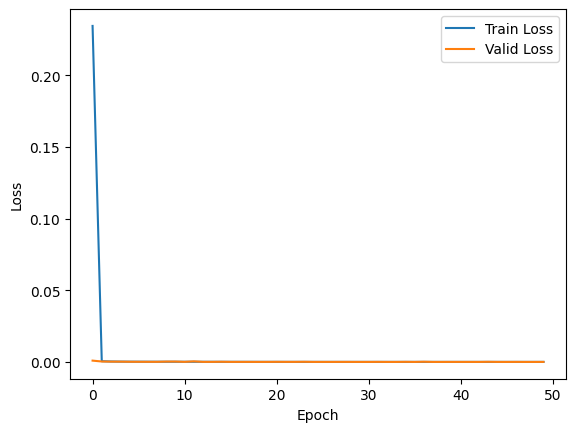

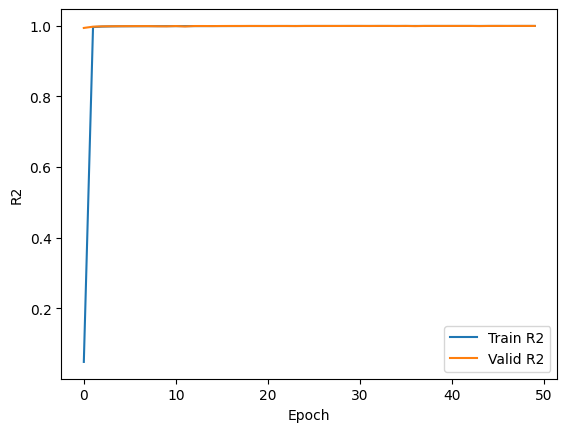

Best validation accuracy: 0.9998628420829773


In [21]:
# TRAINING 
model = TailKinematicsRNN()
# Hyperparameters
learning_rate = 1e-3
num_epochs = 50

# Loss and optimizer
criterion = nn.MSELoss()
# criterion = my_custom_loss
optimizer = optim.Adam(model.parameters(), lr=learning_rate)


model = train_model(model, criterion, optimizer, best_model_file_name= 'kinematicsMoments', num_epochs = num_epochs)

In [17]:
# TESTING
import torch
from torcheval.metrics.functional import mean_squared_error, r2_score
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
# Load the best model
import nn_fncs
model = TailKinematicsRNN()
model_path = nn_fncs.best_model_path('./BestModel/', model_name='kinematicsMoments')
model.load_state_dict(torch.load('./BestModel/' + model_path))
model = model.to(device)

#evaluate the model
model.eval()
print(f"Using device: {device}")
test_dataset_input = test_dataset_input.to(device)
test_dataset_output = test_dataset_output.to(device)
pred = model(test_dataset_input)

mse = mean_squared_error(pred,test_dataset_output)
print(f'MSE loss on test dataset: {mse:1.5E}')
r2 = r2_score(pred,test_dataset_output)
print(f'R2 on test dataset: {r2:1.5E}')

Best model loaded: kinematicsMoments_0.9998628421.pt (Accuracy: 0.9998628421%)
Using device: cuda:0
MSE loss on test dataset: 1.81216E-05
R2 on test dataset: 9.99864E-01


In [9]:
total_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {total_params}")

Number of parameters: 172


In [10]:
# Calculate prediction time
import time
model.eval()
torch.no_grad()
data = torch.randn((1,9,1), dtype=torch.float32).to(device)
start_time = time.time()
pred = model(data)
end_time = time.time()
print(f"Prediction time for one sample: {end_time - start_time:1.5E} seconds")




Prediction time for one sample: 4.00972E-03 seconds


In [11]:
# Calculate prediction time
import time
import torch
model.eval()
torch.no_grad()
torch.set_float32_matmul_precision('medium')
data = torch.randn((1,9,1), dtype=torch.float32).to(device)
start = time.perf_counter()
pred = model(data)
end = time.perf_counter()
print(f"Prediction time for one sample: {end - start:1.5E} seconds")
# Prediction time for one sample: 2.61640E-03 seconds
pred.shape

Prediction time for one sample: 1.67570E-03 seconds


torch.Size([1, 3])

In [25]:
# Test on real simulation data
# load mat file
mat_data= scipy.io.loadmat('../DeltaRData/data2025-10-17_23-21-22.mat', )
motor_angles = mat_data.get('cal_stout')[:,:8]* math.pi/180  # Convert degrees to radians
tail_centre = mat_data.get('Tail_Centre_out')* math.pi/180  # Convert degrees to radians
# prepare input tensor
input_data = np.hstack((motor_angles, tail_centre))
input_data = np.expand_dims(input_data, axis=2)
input_tensor = torch.tensor(input_data, dtype=torch.float32).to(device)
# Simulation output for comparison
moments = mat_data.get('Moments_Add_out')
caudal_fin_data = mat_data.get('cout')  
caudal_fin_data[:, -1] = caudal_fin_data[:, -1] * math.pi/180  # Convert last column to radians
output_data= np.hstack((moments, caudal_fin_data))
output_tensor = torch.tensor(output_data, dtype=torch.float32).to(device)
# Get model predictions
model.eval()
with torch.no_grad():
    pred = model(input_tensor)
# Calculate MSE and R2
mse = mean_squared_error(pred,output_tensor)
r2 = r2_score(output_tensor.cpu(), pred.cpu())
print(f'MSE loss on simulation data: {mse:1.2E}')
print(f'R2 on simulation data: {r2:1.2E}')

MSE loss on simulation data: 1.07E-05
R2 on simulation data: 9.98E-01


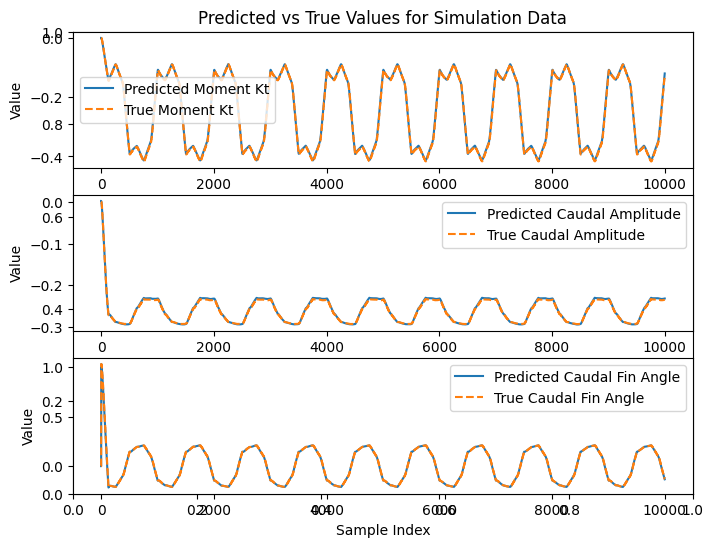

In [26]:
# Plot target vs predicted for simulation data
import matplotlib.pyplot as plt
labels = ['Moment Kt', 'Caudal Amplitude', 'Caudal Fin Angle']
plt.figure(figsize=(8, 6))
plt.title('Predicted vs True Values for Simulation Data')
for i in range(pred.shape[1]):
    plt.subplot(3, 1, i+1)
    plt.plot(pred[: ,i].cpu().detach().numpy(), label=f'Predicted {labels[i]}')
    plt.plot(output_tensor[:, i].cpu().numpy(), label=f'True {labels[i]}', linestyle='dashed')
    plt.xlabel('Sample Index')
    plt.ylabel('Value')
    plt.legend()

plt.show()